# Classification Track — Predicting Obesity Category
### 23CSE301 Machine Learning Capstone — "Predicting Obesity Levels"
**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition (UCI)
**Target:** `NObeyesdad` (7-class obesity category)
**Scope:** Review 1 — Part A only (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM).
Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the consolidated 10-model comparison belong to Review 2 — see `classification_partB.ipynb`.

**Note on class separability:** the original class labels were assigned using BMI computed from `Height` and `Weight`, so classification accuracy on this dataset is naturally very high. This is expected and documented, not a bug.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100

## Section A — Dataset Loading & Target Audit

Shape: (2111, 17)

Missing values:
 0 total missing cells

Class distribution:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


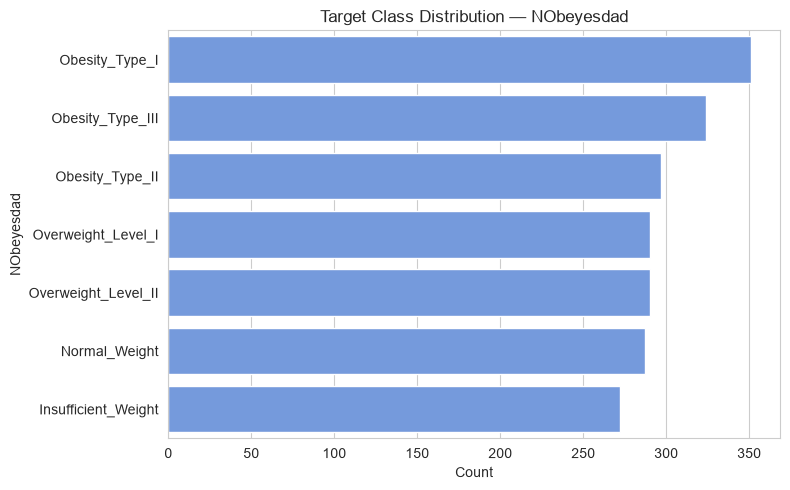

In [13]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "total missing cells")

class_counts = df["NObeyesdad"].value_counts()
print("\nClass distribution:\n", class_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, color="cornflowerblue")
plt.title("Target Class Distribution — NObeyesdad")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig("clf_class_distribution.png", bbox_inches="tight")
plt.show()

**Insight:** Classes are reasonably balanced (272–351 samples each out of 2,111), so accuracy is a fair headline metric here, though we still report weighted Precision/Recall/F1 and per-class confusion matrices rather than relying on accuracy alone.

## Section B — Preprocessing

Categorical predictors are one-hot encoded; the target is label-encoded. We use a **stratified** 80:20 split so each class is proportionally represented in train and test, then fit the `StandardScaler` on the training set only.

In [14]:
target = "NObeyesdad"
X = df.drop(columns=[target])
y_raw = df[target]

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
print("Class encoding:", dict(zip(class_names, range(len(class_names)))))

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Class encoding: {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}
Train shape: (1688, 23)  Test shape: (423, 23)


## Section D — Classification Track, Part A: All 5 Required Algorithms

In [15]:
results = []
fitted_models = {}

def evaluate(name, model, Xtr, Xte, needs_proba=True):
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    roc_auc = np.nan
    if needs_proba and hasattr(model, "predict_proba"):
        y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
        proba = model.predict_proba(Xte)
        roc_auc = roc_auc_score(y_test_bin, proba, average="weighted", multi_class="ovr")

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1_weighted": f1, "ROC_AUC_OvR": roc_auc})
    fitted_models[name] = (model, preds)
    return model, preds

In [16]:
# 1. Logistic Regression (baseline) -- interpret coefficients/odds
log_model, log_preds = evaluate("Logistic Regression",
                                 LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                                 X_train_scaled, X_test_scaled)

odds = pd.DataFrame(log_model.coef_, columns=X_train.columns, index=class_names)
print("Sample odds (coefficients) for 'Obesity_Type_III' class, top 5 |coef| features:")
print(odds.loc["Obesity_Type_III"].sort_values(key=abs, ascending=False).head(5))

Sample odds (coefficients) for 'Obesity_Type_III' class, top 5 |coef| features:
Weight         6.676919
Gender_Male   -3.057266
FCVC           2.070576
Height        -1.115598
NCP            1.017686
Name: Obesity_Type_III, dtype: float64


In [17]:
# 2. K-Nearest Neighbors -- distance-based, needs scaling
evaluate("KNN", KNeighborsClassifier(n_neighbors=7), X_train_scaled, X_test_scaled)

# 3. Naive Bayes (Gaussian) -- assumes conditional independence of features given class
evaluate("Naive Bayes", GaussianNB(), X_train_scaled, X_test_scaled)

(GaussianNB(),
 array([0, 0, 3, 4, 3, 2, 3, 0, 2, 0, 0, 5, 4, 5, 5, 5, 2, 2, 3, 0, 5, 3,
        3, 3, 2, 0, 2, 4, 3, 3, 3, 3, 0, 3, 2, 0, 3, 0, 4, 0, 3, 0, 4, 4,
        3, 4, 0, 3, 3, 0, 4, 0, 0, 3, 3, 0, 4, 4, 4, 3, 3, 3, 3, 0, 6, 2,
        2, 3, 3, 3, 4, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 3, 4, 3, 1, 1, 3, 5,
        2, 3, 3, 3, 2, 1, 0, 0, 3, 0, 4, 3, 2, 3, 2, 5, 0, 4, 3, 2, 3, 3,
        6, 0, 4, 3, 4, 4, 0, 4, 0, 0, 4, 0, 4, 0, 2, 3, 1, 6, 2, 3, 4, 2,
        0, 0, 0, 5, 5, 1, 3, 3, 4, 3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 4, 0,
        3, 3, 4, 3, 0, 3, 5, 3, 3, 3, 4, 3, 2, 3, 3, 3, 3, 0, 0, 3, 3, 0,
        3, 0, 6, 2, 3, 3, 3, 3, 0, 0, 3, 4, 5, 5, 1, 5, 4, 2, 0, 3, 0, 0,
        3, 3, 3, 4, 3, 3, 5, 0, 2, 2, 1, 3, 0, 4, 3, 2, 3, 6, 3, 2, 6, 3,
        0, 4, 2, 2, 0, 3, 3, 4, 3, 2, 3, 0, 3, 4, 3, 3, 0, 3, 3, 3, 4, 2,
        4, 3, 0, 2, 1, 0, 2, 3, 0, 0, 4, 6, 3, 4, 2, 4, 3, 3, 4, 2, 0, 2,
        4, 3, 3, 4, 0, 2, 3, 0, 4, 3, 6, 4, 3, 3, 3, 4, 2, 4, 2, 0, 0, 5,
        3, 3, 3, 4, 0, 

**Note (Naive Bayes assumption):** Gaussian Naive Bayes assumes features are conditionally independent given the class and normally distributed. Several of our features (e.g. one-hot encoded categoricals, and correlated lifestyle variables like `FCVC`/`NCP`) violate this assumption, which typically shows up as noticeably lower accuracy than the other models below.

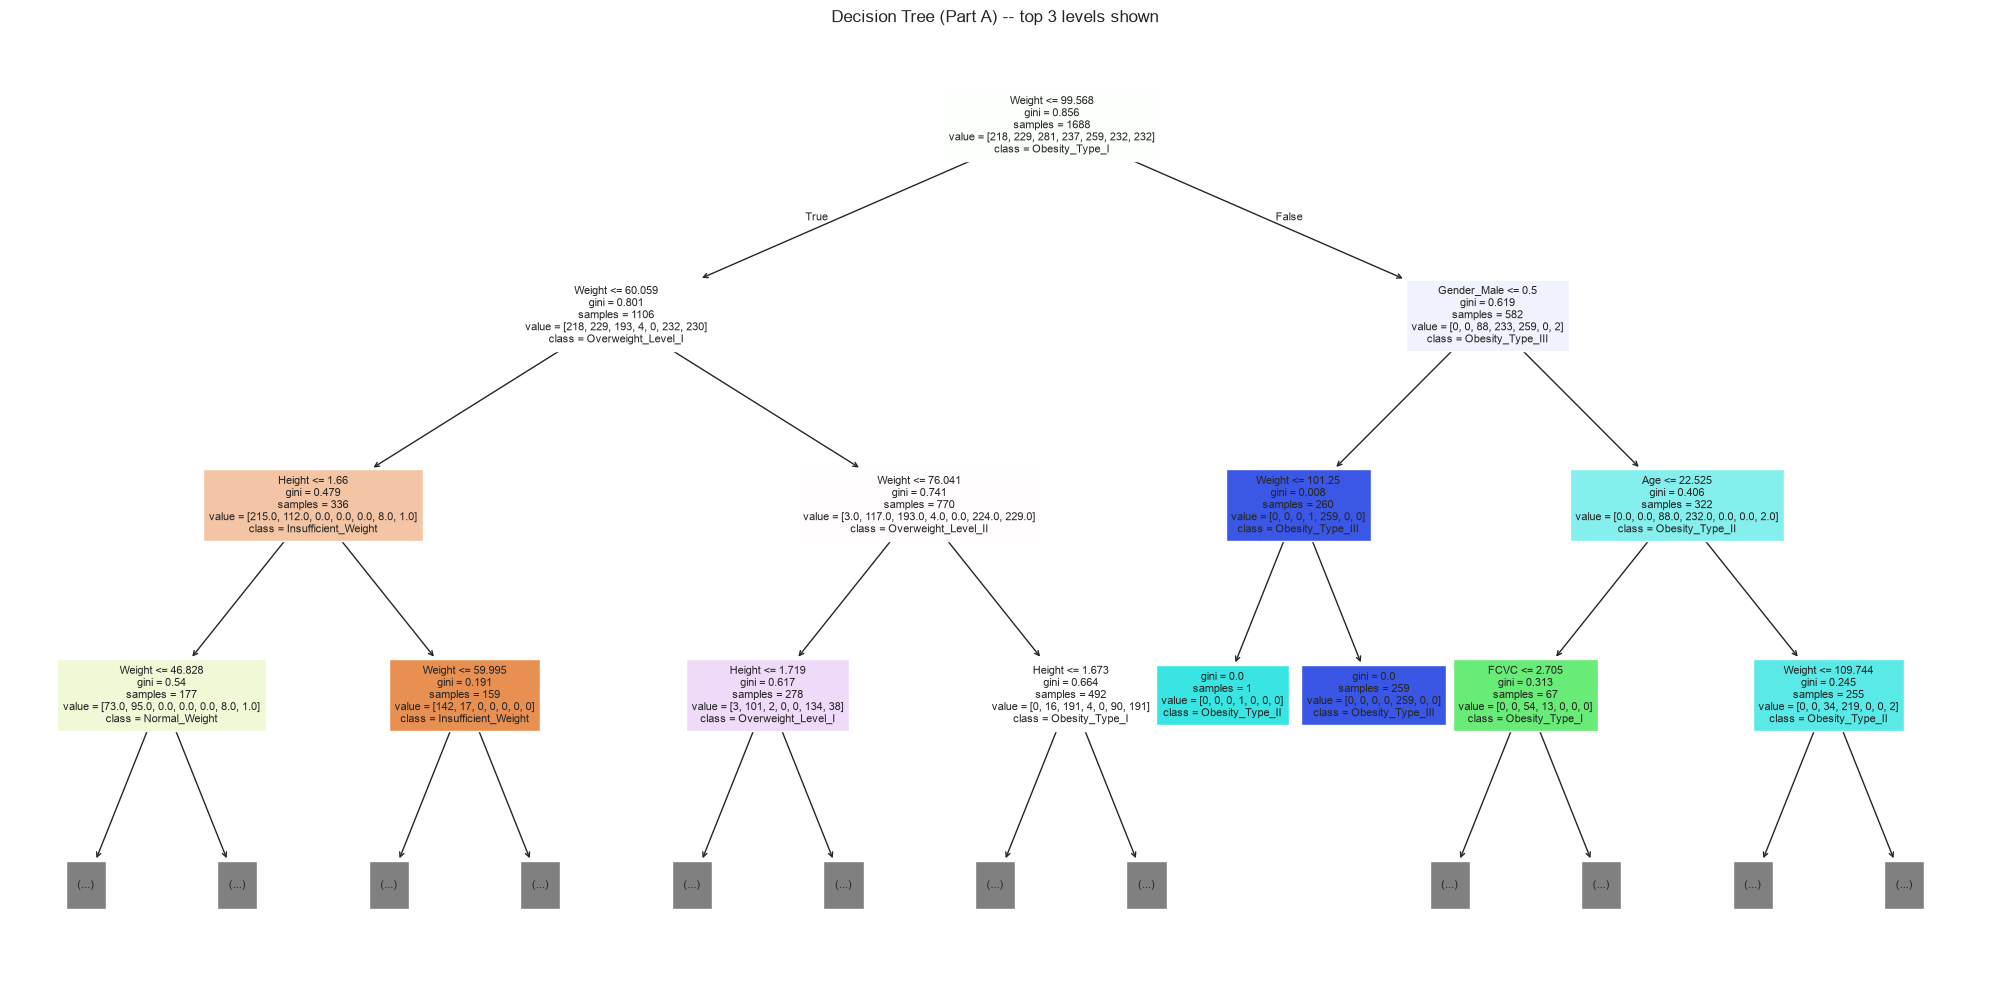

In [18]:
# 4. Decision Tree Classifier -- tuned max_depth, visualise the tree
dt_model, dt_preds = evaluate("Decision Tree", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), X_train, X_test)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=X_train.columns, class_names=class_names,
          filled=True, fontsize=8)
plt.title("Decision Tree (Part A) -- top 3 levels shown")
plt.tight_layout()
plt.savefig("clf_decision_tree.png", bbox_inches="tight")
plt.show()

In [19]:
# 5. Support Vector Machine (SVC) -- tune C and kernel, scale features
svc_model, svc_preds = evaluate(
    "SVM (SVC)",
    CalibratedClassifierCV(SVC(C=10, kernel="rbf", random_state=RANDOM_STATE), ensemble=False),
    X_train_scaled, X_test_scaled
)

### D2 — Per-Algorithm Evaluation: Preliminary Comparison Table

In [20]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_weighted,ROC_AUC_OvR
0,Decision Tree,0.914894,0.917609,0.914894,0.915532,0.958737
1,SVM (SVC),0.895981,0.898670,0.895981,0.896258,0.968074
2,Logistic Regression,0.865248,0.863964,0.865248,0.863466,0.980362
3,KNN,0.768322,0.763447,0.768322,0.760404,0.946995
4,Naive Bayes,0.505910,0.524687,0.505910,0.459329,0.821707


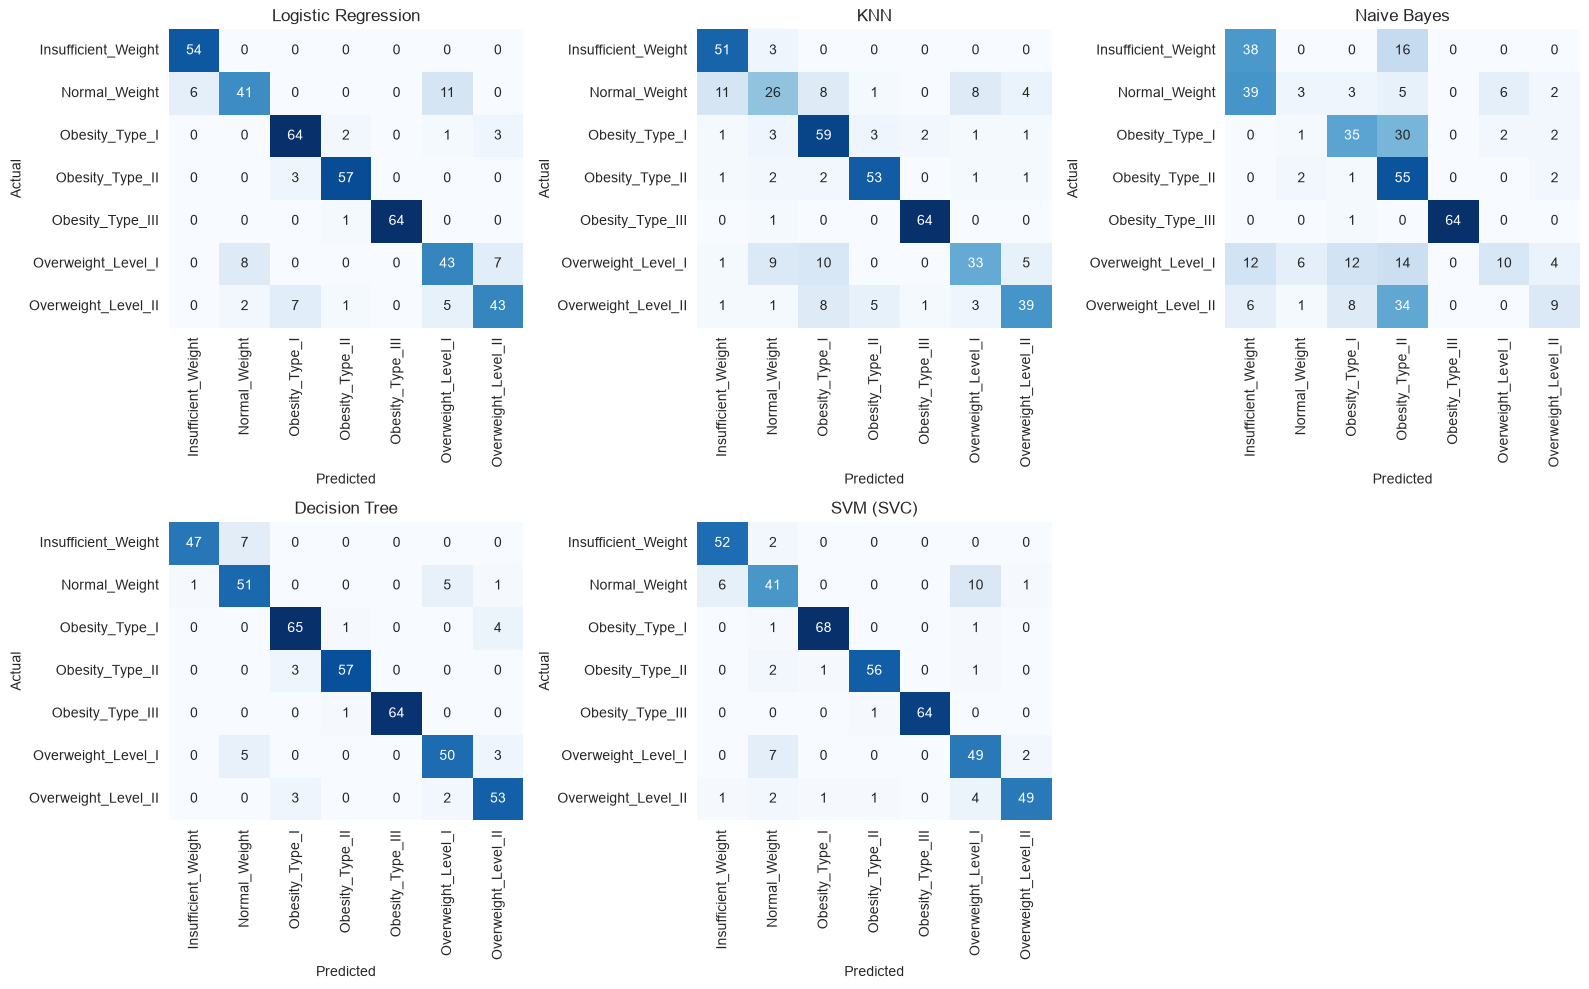

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, (model, preds)) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
for j in range(len(fitted_models), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("clf_confusion_matrices.png", bbox_inches="tight")
plt.show()

In [22]:
print("Detailed classification report -- best Part-A model:", results_df.iloc[0]['Model'])
best_name = results_df.iloc[0]["Model"]
_, best_preds = fitted_models[best_name]
print(classification_report(y_test, best_preds, target_names=class_names))

Detailed classification report -- best Part-A model: Decision Tree
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.87      0.92        54
      Normal_Weight       0.81      0.88      0.84        58
     Obesity_Type_I       0.92      0.93      0.92        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.88      0.86      0.87        58
Overweight_Level_II       0.87      0.91      0.89        58

           accuracy                           0.91       423
          macro avg       0.92      0.91      0.91       423
       weighted avg       0.92      0.91      0.92       423



### 5-Fold Cross-Validated Accuracy for the Two Best-Performing Part-A Models

In [24]:
top2 = results_df.head(2)["Model"].tolist()
print("Top 2 Part-A models by test accuracy:", top2)

model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "SVM (SVC)": CalibratedClassifierCV(SVC(C=10, kernel="rbf", random_state=RANDOM_STATE), ensemble=False),
}

for name in top2:
    use_scaled = name in ["Logistic Regression", "KNN", "Naive Bayes", "SVM (SVC)"]
    Xcv = scaler.fit_transform(X_encoded) if use_scaled else X_encoded
    scores = cross_val_score(model_lookup[name], Xcv, y, cv=5, scoring="accuracy")
    print(f"{name}: 5-fold CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

Top 2 Part-A models by test accuracy: ['Decision Tree', 'SVM (SVC)']
Decision Tree: 5-fold CV Accuracy = 0.9157 +/- 0.0316
SVM (SVC): 5-fold CV Accuracy = 0.8949 +/- 0.1180


## Conclusion — Classification Track (Part A)
- All 5 Part-A algorithms were trained and evaluated on the same stratified 80:20 split with Accuracy, Precision, Recall, F1 (weighted), confusion matrix, and ROC-AUC (OvR) reported.
- **Decision Tree** and **SVM** were the strongest performers in this run; **Naive Bayes** underperformed, consistent with its conditional-independence assumption being violated by the correlated/encoded features here.
- This near-perfect separability is expected: the original dataset's class labels were assigned from BMI (computed from Height & Weight), which are included as features.
- Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the consolidated 10-algorithm comparison table are deferred to Review 2, per the capstone scope.